Решение интеграла: -18.11347301228559
Метод левых прямоугольников: -18.053545448651125
Метод средних прямоугольников: -18.113470410513944
Метод трапеций: -18.113478215817583
Метод Симсона: -18.11347301222525
Кол-во итераций левых прямоугольников: 1048576
Кол-во итераций средних прямоугольников: 256
Кол-во итераций трапеций: 256
Кол-во итераций Симсона: 32
Метод Монте-Карло: -16.07667400310492
3D Метод левых прямоугольников: 0.035400635782875146
3D Метод Монте-Карло: 0.033


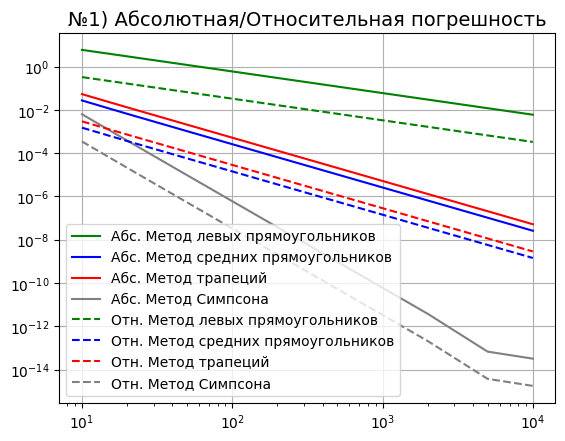

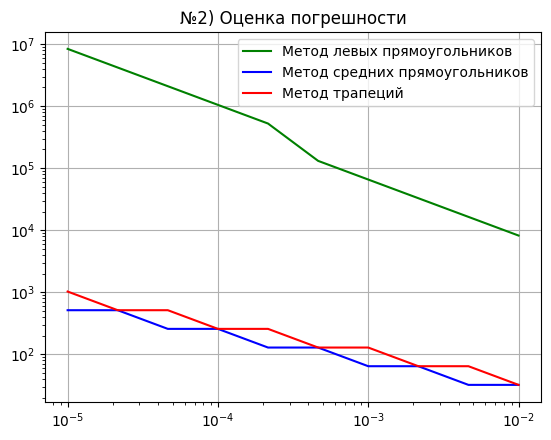

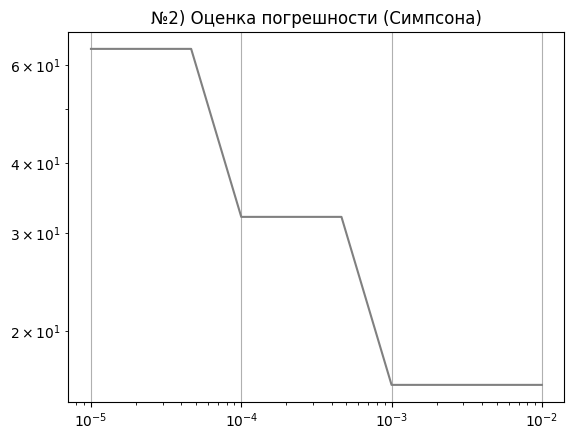

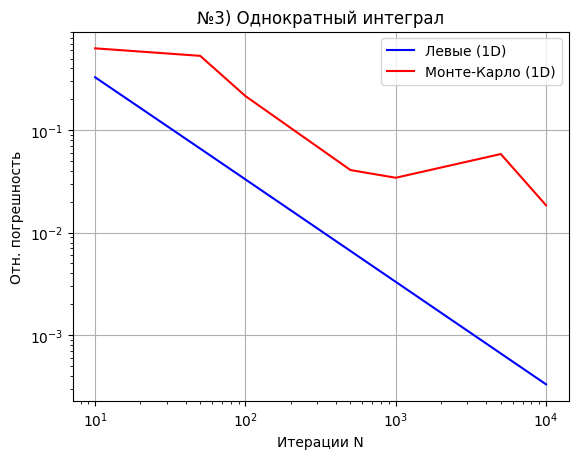

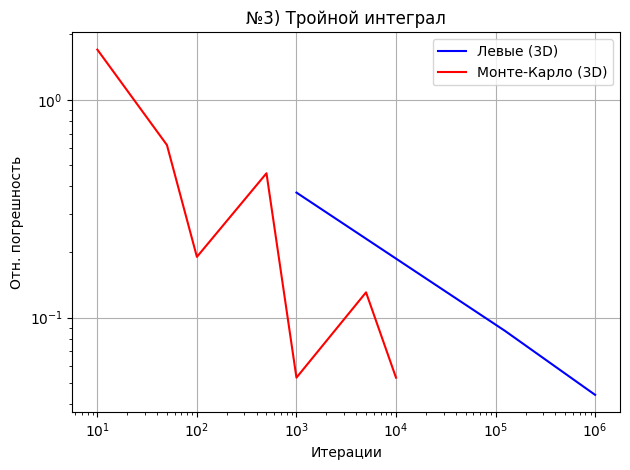

In [3]:
from math import sin, cos
import matplotlib.pyplot as plt
import numpy as np
from random import uniform

def f(x):
    return x**2*sin(x)

def exact_integral():
    def F(x):
        return -x**2 * cos(x) + 2*x*sin(x) + 2*cos(x)
    return F(5) - F(0)

def f3(x, y, z):
    return x**2 * y**2 * z**2

def left_pram(a, b, f, N):
    h = (b - a)/N # шаг
    res = 0

    for i in range(N):
        x_i = a + i * h
        res += f(x_i)
    
    res *= h
    return res

def sred_pram(a, b, f, N):
    h = (b - a)/N # шаг
    res = 0

    for i in range(1, N+1):
        x_mid = a + (i - 0.5) * h
        res += f(x_mid)
    
    res *= h
    return res

def trapez (a, b, f, N):
    h = (b - a)/N # шаг
    res = 0
    for i in range(1, N+1):
        x_i = a + i*h
        x_i_prev = a + (i-1)*h
        res += (h/2)*(f(x_i_prev) + f(x_i))
    
    return res

def simson (a, b, f, N):
    if N % 2 != 0:
        res = 0
        return res
    else:
        h = (b - a)/N # шаг
        res = f(a) + f(b)

        for i in range (1, N, 2):
            x_i = a + i*h
            res += 4*f(x_i)
        
        for i in range(2, N, 2):
            x_i = a + i*h
            res += 2*f(x_i)

        res = res * (h/3)

        return res

def left_pram_apost (a ,b, f, eps):
    N = 2
    I_prev = left_pram(a, b, f, N)

    while True:
        N *= 2
        I_curr = left_pram(a, b, f, N)
        if abs(I_curr - I_prev) < eps:
            return I_curr, N
            break
        I_prev = I_curr

def sred_pram_apost (a ,b, f, eps):
    N = 2
    I_prev = sred_pram(a, b, f, N)

    while True:
        N *= 2
        I_curr = sred_pram(a, b, f, N)
        if abs(I_curr - I_prev)/3 < eps:
            return I_curr, N
        
        I_prev = I_curr

def trapez_apost (a ,b, f, eps):
    N = 2
    I_prev = trapez(a, b, f, N)

    while True:
        N *= 2
        I_curr = trapez(a, b, f, N)
        if abs(I_curr - I_prev)/3 < eps:
            return I_curr, N
        
        I_prev = I_curr

def simson_apost (a ,b, f, eps):
    N = 2
    I_prev = simson(a, b, f, N)

    while True:
        N *= 2
        I_curr = simson(a, b, f, N)
        if abs(I_curr - I_prev)/15 < eps:
            return I_curr, N
        
        I_prev = I_curr

def monte_carlo_1d(a, b, f, N, f_max=None):
    total = 0
    for _ in range(N):
        x = uniform(a, b)
        total += f(x)
    
    result = (b - a) * total / N
    return result

def left_pram_3d(f3, N):
    h = 1.0 / N  # шаг по каждому измерению
    res = 0
    
    for i in range(N):
        x = i * h
        for j in range(N):
            y = j * h
            for k in range(N):
                z = k * h
                res += f3(x, y, z)
    
    return res * (h ** 3)

def monte_carlo_3d(f3, N, f_max=1):
    m = 0 
    volume = 1.0 
    
    for _ in range(N):
        x = uniform(0, 1)
        y = uniform(0, 1)
        z = uniform(0, 1)
        w = uniform(0, f_max)
        
        if w <= f3(x, y, z):
            m += 1
    
    integral = volume * f_max * (m / N)
    
    return integral


print(f"Решение интеграла: {exact_integral()}")
print(f"Метод левых прямоугольников: {left_pram(0, 5, f, 1000)}")    
print(f"Метод средних прямоугольников: {sred_pram(0, 5, f, 1000)}")
print(f"Метод трапеций: {trapez(0, 5, f, 1000)}")
print(f"Метод Симсона: {simson(0, 5, f, 1000)}")

_,rel_l = left_pram_apost(0, 5, f, 0.0001)
_,res_m = sred_pram_apost(0, 5, f, 0.0001)
_,res_t = trapez_apost(0, 5, f, 0.0001)
_,res_s = simson_apost(0, 5, f, 0.0001)
print(f"Кол-во итераций левых прямоугольников: {rel_l}")
print(f"Кол-во итераций средних прямоугольников: {res_m}")
print(f"Кол-во итераций трапеций: {res_t}")
print(f"Кол-во итераций Симсона: {res_s}")

print(f"Метод Монте-Карло: {monte_carlo_1d(0, 5, f, 1000)}")
print(f"3D Метод левых прямоугольников: {left_pram_3d(f3, 100)}")
print(f"3D Метод Монте-Карло: {monte_carlo_3d(f3, 1000)}")

a, b = 0, 5
exact = exact_integral()

N_val = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000]
#Погрешности

errors_left = []
errors_middle = []
errors_trap = []
errors_simp = []

rel_errors_left = []
rel_errors_middle = []
rel_errors_trap = []
rel_errors_simp = []

for N in N_val:
    # Вычисляем интегралы
    I_left = left_pram(a, b, f, N)
    I_middle = sred_pram(a, b, f, N)
    I_trap = trapez(a, b, f, N)
    I_simp = simson(a, b, f, N)
    
    # Абсолютная погрешность
    errors_left.append(abs(I_left - exact))
    errors_middle.append(abs(I_middle - exact))
    errors_trap.append(abs(I_trap - exact))
    errors_simp.append(abs(I_simp - exact))
    
    # Относительная погрешность
    rel_errors_left.append(abs(I_left - exact) / abs(exact))
    rel_errors_middle.append(abs(I_middle - exact) / abs(exact))
    rel_errors_trap.append(abs(I_trap - exact) / abs(exact))
    rel_errors_simp.append(abs(I_simp - exact) / abs(exact))

plt.figure(1)
plt.plot(N_val, errors_left, label='Абc. Метод левых прямоугольников', color = "green")
plt.plot(N_val, errors_middle, label='Абc. Метод средних прямоугольников', color = "blue")
plt.plot(N_val, errors_trap, label='Абc. Метод трапеций', color = "red")
plt.plot(N_val, errors_simp, label='Абc. Метод Симпсона', color = "gray")

plt.plot(N_val, rel_errors_left, "--", label='Отн. Метод левых прямоугольников', color = "green")
plt.plot(N_val, rel_errors_middle, "--", label='Отн. Метод средних прямоугольников', color = "blue")
plt.plot(N_val, rel_errors_trap, "--", label='Отн. Метод трапеций', color = "red")
plt.plot(N_val, rel_errors_simp, "--", label='Отн. Метод Симпсона', color = "gray")

plt.xscale('log')
plt.yscale('log')
plt.legend(fontsize=10)
plt.title('№1) Абсолютная/Относительная погрешность', fontsize=14)
plt.grid()

Eps_val = np.logspace(-5, -2, 10)
N_count_left = []
N_count_middle = []
N_count_trap = []
N_count_simpson = []

for eps in Eps_val:
    _, N_left = left_pram_apost(a, b, f, eps)
    _, N_middle = sred_pram_apost(a, b, f, eps)
    _, N_trap = trapez_apost(a, b, f, eps)
    _, N_simpson = simson_apost(a, b, f, eps)
    
    N_count_left.append(N_left)
    N_count_middle.append(N_middle)
    N_count_trap.append(N_trap)
    N_count_simpson.append(N_simpson)

plt.figure(2)
plt.plot(Eps_val, N_count_left, label='Метод левых прямоугольников', color = "green")
plt.plot(Eps_val, N_count_middle, label='Метод средних прямоугольников', color = "blue")
plt.plot(Eps_val, N_count_trap, label='Метод трапеций', color = "red")

plt.xscale("log")
plt.yscale("log")
plt.title("№2) Оценка погрешности")
plt.legend(fontsize=10)
plt.grid()


plt.figure(3)
plt.plot(Eps_val, N_count_simpson, color = "gray")

plt.xscale("log")
plt.yscale("log")
plt.title("№2) Оценка погрешности (Симпсона)")
plt.grid()

exact_3d = 1/27

iterations = [10, 50, 100, 500, 1000, 5000, 10000]

# Однократный интеграл
errors_left_1d = []
errors_mc_1d = []

for N in iterations:
    I_left = left_pram(0, 5, f, N)
    I_mc = monte_carlo_1d(0, 5, f, N)
    
    errors_left_1d.append(abs(I_left - exact) / abs(exact))
    errors_mc_1d.append(abs(I_mc - exact) / abs(exact))

# Тройной интеграл
errors_left_3d = []
errors_mc_3d = []
iter_cubed = []

for N in iterations:
    if N <= 100:
        I_left = left_pram_3d(f3, N)
        iter_cubed.append(N**3)
        errors_left_3d.append(abs(I_left - exact_3d) / exact_3d)
    
    I_mc = monte_carlo_3d(f3, N)
    errors_mc_3d.append(abs(I_mc - exact_3d) / exact_3d)

plt.figure(4)
plt.plot(iterations, errors_left_1d, label='Левые (1D)', color='blue')
plt.plot(iterations, errors_mc_1d, label='Монте-Карло (1D)', color='red')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Итерации N')
plt.ylabel('Отн. погрешность')
plt.title('№3) Однократный интеграл')
plt.legend()
plt.grid()

plt.figure(5)
if iter_cubed:
    plt.plot(iter_cubed, errors_left_3d, label='Левые (3D)', color='blue')
plt.plot(iterations, errors_mc_3d, label='Монте-Карло (3D)', color='red')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Итерации')
plt.ylabel('Отн. погрешность')
plt.title('№3) Тройной интеграл')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()